# Analyze Results with ALLaM — AraEduAgent

Compares all 5 models (GPT-3.5, GPT-4o Mini, Llama 3.1, Qwen2.5, ALLaM) + ALLaM's 4 strategies.

**Does NOT re-run any experiment.** Reads existing CSV result files only.

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

BASE = 'dataset/simulation/full_experiment_300_students'

# ── Model registry ────────────────────────────────────────────────────────────
# Each entry: (folder_suffix, display_name, color)
BASE_MODELS = [
    ('2',          'GPT-3.5',      '#4878d0'),
    ('3',          'GPT-4o Mini',  '#ee854a'),
    ('4',          'Llama 3.1',    '#6acc65'),
    ('5',          'Qwen2.5',      '#d65f5f'),
]

# ALLaM strategies — folder suffix is gpt_type from agent_config
ALLAM_STRATEGIES = [
    ('allam_s0',   'ALLaM S0',     '#956cb4'),  # baseline
    ('allam_s1',   'ALLaM S1',     '#8c613c'),  # dynamic few-shot
    ('allam_s2',   'ALLaM S2',     '#dc7ec0'),  # prompt compression
    ('allam_s3',   'ALLaM S3',     '#797979'),  # slide chunking
]

# Folder pattern: {source}_{forget}_{reflect}_{mem}_{strat}_{example}_{gpt_type}
# base models use: only_recent_one / KM+PM+MM+CM / standard_cog
# ALLaM s0,s2: same; s1,s3: no_memory / KM / standard_cog or standard
def get_folder(source, gpt_suffix):
    if gpt_suffix in ('allam_s1',):
        return os.path.join(BASE, f'{source}_no_memory_reflect-no_KM_standard_cog_example-no_{gpt_suffix}')
    elif gpt_suffix in ('allam_s3',):
        return os.path.join(BASE, f'{source}_no_memory_reflect-no_KM_standard_example-no_{gpt_suffix}')
    else:
        return os.path.join(BASE, f'{source}_only_recent_one_reflect-no_KM+PM+MM+CM_standard_cog_example-no_{gpt_suffix}')

ALL_MODELS = BASE_MODELS + ALLAM_STRATEGIES
print(f'Models to compare: {len(ALL_MODELS)}')
for suffix, name, _ in ALL_MODELS:
    for src in ['real','sim']:
        folder = get_folder(src, suffix)
        n = len(glob.glob(os.path.join(folder,'log','*_result_ind_dur.csv')))
        print(f'  {name:15} {src:4}: {n} files  ({os.path.basename(folder)})')


Models to compare: 8
  GPT-3.5         real: 301 files  (real_only_recent_one_reflect-no_KM+PM+MM+CM_standard_cog_example-no_2)
  GPT-3.5         sim : 300 files  (sim_only_recent_one_reflect-no_KM+PM+MM+CM_standard_cog_example-no_2)
  GPT-4o Mini     real: 301 files  (real_only_recent_one_reflect-no_KM+PM+MM+CM_standard_cog_example-no_3)
  GPT-4o Mini     sim : 300 files  (sim_only_recent_one_reflect-no_KM+PM+MM+CM_standard_cog_example-no_3)
  Llama 3.1       real: 301 files  (real_only_recent_one_reflect-no_KM+PM+MM+CM_standard_cog_example-no_4)
  Llama 3.1       sim : 300 files  (sim_only_recent_one_reflect-no_KM+PM+MM+CM_standard_cog_example-no_4)
  Qwen2.5         real: 301 files  (real_only_recent_one_reflect-no_KM+PM+MM+CM_standard_cog_example-no_5)
  Qwen2.5         sim : 300 files  (sim_only_recent_one_reflect-no_KM+PM+MM+CM_standard_cog_example-no_5)
  ALLaM S0        real: 300 files  (real_only_recent_one_reflect-no_KM+PM+MM+CM_standard_cog_example-no_allam_s0)
  ALLaM S0   

In [2]:
# ── Load all result CSVs ─────────────────────────────────────────────────────
DUR_METRICS  = ['gaze_aoi_distance','motor_aoi_distance','workload_diff',
                'curiosity_diff','valid_focus_diff','follow_ratio_diff',
                'engagement_accuracy','confusion_accuracy']
POST_METRICS = ['choice_similarity','accuracy_similarity']

def load_experiment(source, gpt_suffix):
    folder = get_folder(source, gpt_suffix)
    dur_files  = glob.glob(os.path.join(folder,'log','*_result_ind_dur.csv'))
    post_files = glob.glob(os.path.join(folder,'log','*_result_ind_post.csv'))
    if not dur_files:
        return None, None
    dur  = pd.concat([pd.read_csv(f) for f in dur_files],  ignore_index=True)
    post = pd.concat([pd.read_csv(f) for f in post_files], ignore_index=True) if post_files else pd.DataFrame()
    return dur, post

results = {}   # (suffix, source) -> {'dur': df, 'post': df, 'n_students': int}
for suffix, name, _ in ALL_MODELS:
    for source in ['real','sim']:
        dur, post = load_experiment(source, suffix)
        if dur is not None:
            n = dur['student_id'].nunique()
            results[(suffix, source)] = {'dur': dur, 'post': post, 'n': n, 'name': name}
            print(f'Loaded {name:15} {source:4}: {n} students')
        else:
            print(f'⚠️  Missing: {name} {source}')


Loaded GPT-3.5         real: 301 students
Loaded GPT-3.5         sim : 300 students
Loaded GPT-4o Mini     real: 301 students
Loaded GPT-4o Mini     sim : 300 students
Loaded Llama 3.1       real: 301 students
Loaded Llama 3.1       sim : 300 students
Loaded Qwen2.5         real: 301 students
Loaded Qwen2.5         sim : 300 students
Loaded ALLaM S0        real: 300 students
Loaded ALLaM S0        sim : 8 students
Loaded ALLaM S1        real: 300 students
Loaded ALLaM S1        sim : 300 students
Loaded ALLaM S2        real: 300 students
Loaded ALLaM S2        sim : 300 students
Loaded ALLaM S3        real: 300 students
Loaded ALLaM S3        sim : 300 students


In [3]:
# ── Compute per-model aggregate metrics ─────────────────────────────────────
def compute_metrics(dur, post):
    m = {}
    if dur is not None and len(dur):
        m['GA']  = dur['gaze_aoi_distance'].mean()
        m['MO']  = dur['motor_aoi_distance'].mean()
        m['WO']  = dur['workload_diff'].abs().mean()
        m['CU']  = dur['curiosity_diff'].abs().mean()
        m['FOC'] = dur['valid_focus_diff'].abs().mean()
        m['FOL'] = dur['follow_ratio_diff'].abs().mean()
        m['ENG'] = dur['engagement_accuracy'].mean()
        m['CO']  = dur['confusion_accuracy'].mean()
    if post is not None and len(post):
        m['CH']  = post['choice_similarity'].mean() * 100
        m['COR'] = post['accuracy_similarity'].mean() * 100
    return m

rows = []
for suffix, name, color in ALL_MODELS:
    for source in ['real','sim']:
        key = (suffix, source)
        if key not in results: continue
        r = results[key]
        m = compute_metrics(r['dur'], r['post'])
        row = {'Model': name, 'Suffix': suffix, 'Exp': source.capitalize(), 'N': r['n'], 'Color': color}
        row.update(m)
        rows.append(row)

df_all = pd.DataFrame(rows)
cols = ['Model','Exp','N','GA','MO','WO','CU','FOC','FOL','ENG','CO','CH','COR']
cols = [c for c in cols if c in df_all.columns]
print(df_all[cols].to_string(index=False, float_format='{:.3f}'.format))


      Model  Exp   N    GA    MO    WO    CU   FOC   FOL   ENG    CO     CH    COR
    GPT-3.5 Real 301 0.338 0.304 0.225 0.228 0.267 0.357 0.173 0.159 46.905 55.627
    GPT-3.5  Sim 300 0.352 0.330 0.326 0.348 0.296 0.462 0.367 0.332 46.618 55.598
GPT-4o Mini Real 301 0.371 0.327 0.167 0.213 0.257 0.351 0.149 0.090 61.858 66.074
GPT-4o Mini  Sim 300 0.372 0.329 0.244 0.423 0.348 0.422 0.476 0.321 61.094 65.986
  Llama 3.1 Real 301 0.355 0.334 0.213 0.262 0.271 0.386 0.106 0.061 45.684 55.727
  Llama 3.1  Sim 300 0.369 0.356 0.370 0.552 0.423 0.615 0.390 0.301 45.016 55.431
    Qwen2.5 Real 301 0.390 0.348 0.177 0.226 0.242 0.403 0.071 0.038 57.429 61.995
    Qwen2.5  Sim 300 0.375 0.338 0.224 0.396 0.372 0.470 0.416 0.251 56.928 61.288
   ALLaM S0 Real 300 0.349 0.341 0.223 0.210 0.368 0.371 0.306 0.068 48.643 56.109
   ALLaM S0  Sim   8 0.360 0.352 0.219 0.242 0.333 0.522 0.390 0.157 56.250 59.375
   ALLaM S1 Real 300 0.353 0.337 0.253 0.282 0.431 0.455 0.502 0.111 47.832 57.781
   A

In [4]:
# ── Table 1: Full Benchmark (paper-style) ───────────────────────────────────
float_cols = ['GA','MO','WO','CU','FOC','FOL','ENG','CO','CH','COR']
float_cols = [c for c in float_cols if c in df_all.columns]

def highlight_best(df, cols, lower_better_cols):
    """Bold the best value per column."""
    styled = df.style
    for col in cols:
        if col not in df.columns: continue
        vals = df[col].dropna()
        best = vals.min() if col in lower_better_cols else vals.max()
        styled = styled.apply(
            lambda s, b=best: ['font-weight: bold' if abs(v-b)<1e-6 else '' for v in s],
            subset=[col]
        )
    return styled

lower_better = ['GA','MO','WO','CU','FOC','FOL']
display_df = df_all[['Model','Exp','N']+float_cols].copy()
for c in float_cols:
    if c in ['CH','COR']:
        display_df[c] = display_df[c].map('{:.1f}'.format)
    else:
        display_df[c] = display_df[c].map('{:.3f}'.format)

try:
    from IPython.display import display
    display(display_df)
except:
    print(display_df.to_string(index=False))

# Save to CSV
os.makedirs(os.path.join(BASE,'figures_and_tables'), exist_ok=True)
df_all[['Model','Suffix','Exp','N']+float_cols].to_csv(
    os.path.join(BASE,'figures_and_tables','benchmark_with_allam.csv'), index=False
)
print('\n✅ Saved: figures_and_tables/benchmark_with_allam.csv')


,Model,Exp,N,GA,MO,WO,CU,FOC,FOL,ENG,CO,CH,COR
0,GPT-3.5,Real,301,0.338,0.304,0.225,0.228,0.267,0.357,0.173,0.159,46.9,55.6
1,GPT-3.5,Sim,300,0.352,0.330,0.326,0.348,0.296,0.462,0.367,0.332,46.6,55.6
2,GPT-4o Mini,Real,301,0.371,0.327,0.167,0.213,0.257,0.351,0.149,0.090,61.9,66.1
3,GPT-4o Mini,Sim,300,0.372,0.329,0.244,0.423,0.348,0.422,0.476,0.321,61.1,66.0
4,Llama 3.1,Real,301,0.355,0.334,0.213,0.262,0.271,0.386,0.106,0.061,45.7,55.7
5,Llama 3.1,Sim,300,0.369,0.356,0.370,0.552,0.423,0.615,0.390,0.301,45.0,55.4
6,Qwen2.5,Real,301,0.390,0.348,0.177,0.226,0.242,0.403,0.071,0.038,57.4,62.0
7,Qwen2.5,Sim,300,0.375,0.338,0.224,0.396,0.372,0.470,0.416,0.251,56.9,61.3
8,ALLaM S0,Real,300,0.349,0.341,0.223,0.210,0.368,0.371,0.306,0.068,48.6,56.1
9,ALLaM S0,Sim,8,0.360,0.352,0.219,0.242,0.333,0.522,0.390,0.157,56.2,59.4



✅ Saved: figures_and_tables/benchmark_with_allam.csv


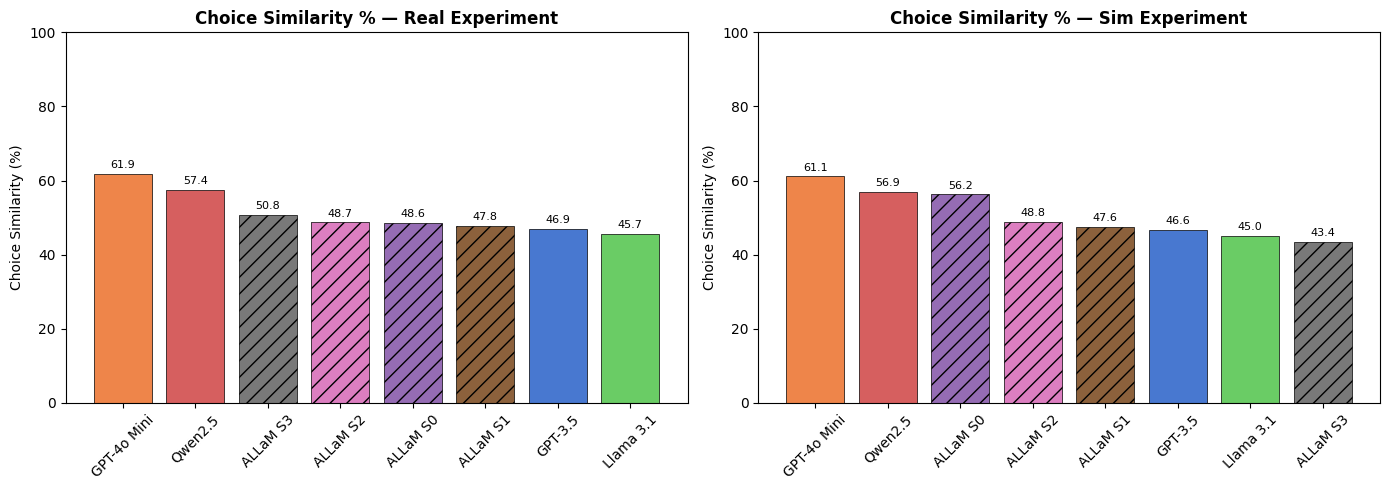

✅ Saved: fig_choice_similarity_with_allam.png


In [5]:
# ── Figure: CH (Choice Similarity) bar chart — Real experiments ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp in zip(axes, ['Real','Sim']):
    sub = df_all[df_all['Exp']==exp].copy()
    if sub.empty or 'CH' not in sub.columns: continue
    sub = sub.sort_values('CH', ascending=False)
    colors = [sub.loc[i,'Color'] for i in sub.index]
    bars = ax.bar(sub['Model'], sub['CH'], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(f'Choice Similarity % — {exp} Experiment', fontsize=12, fontweight='bold')
    ax.set_ylabel('Choice Similarity (%)')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, sub['CH']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)
    # Highlight ALLaM strategies
    for bar, name in zip(bars, sub['Model']):
        if 'ALLaM' in name:
            bar.set_hatch('//')

plt.tight_layout()
plt.savefig(os.path.join(BASE,'figures_and_tables','fig_choice_similarity_with_allam.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: fig_choice_similarity_with_allam.png')


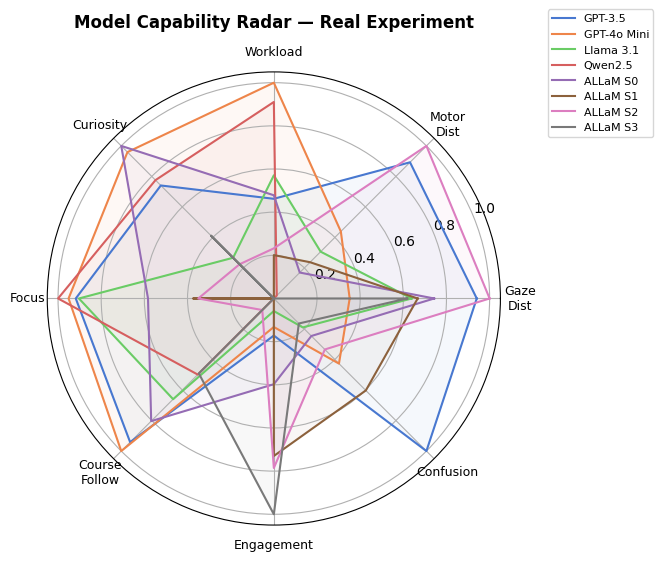

✅ Saved: fig_radar_with_allam.png


In [7]:
# ── Figure: Radar chart — Real experiment, all models ───────────────────────
radar_metrics = ['GA','MO','WO','CU','FOC','FOL','ENG','CO']
radar_labels  = ['Gaze\nDist','Motor\nDist','Workload','Curiosity',
                 'Focus','Course\nFollow','Engagement','Confusion']

# Normalise to [0,1] per metric (lower = better → invert lower_better)
real_df = df_all[df_all['Exp']=='Real'].copy()
radar_cols = [c for c in radar_metrics if c in real_df.columns]
if len(radar_cols) < 3:
    print('⚠️  Not enough metrics for radar chart. Run experiments first.')
else:
    norm = real_df[radar_cols].copy()
    for col in radar_cols:
        mn, mx = norm[col].min(), norm[col].max()
        if mx > mn:
            if col in lower_better:
                norm[col] = 1 - (norm[col]-mn)/(mx-mn)  # invert: lower=better=higher score
            else:
                norm[col] = (norm[col]-mn)/(mx-mn)

    angles = np.linspace(0, 2*np.pi, len(radar_cols), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7,7), subplot_kw={'polar': True})
    for _, row in real_df.iterrows():
        values = norm.loc[row.name, radar_cols].tolist()
        values += values[:1]
        ax.plot(angles, values, label=row['Model'], color=row['Color'], linewidth=1.5)
        ax.fill(angles, values, alpha=0.05, color=row['Color'])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([radar_labels[i] for i in range(len(radar_cols))], fontsize=9)
    ax.set_title('Model Capability Radar — Real Experiment', y=1.08, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE,'figures_and_tables','fig_radar_with_allam.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: fig_radar_with_allam.png')


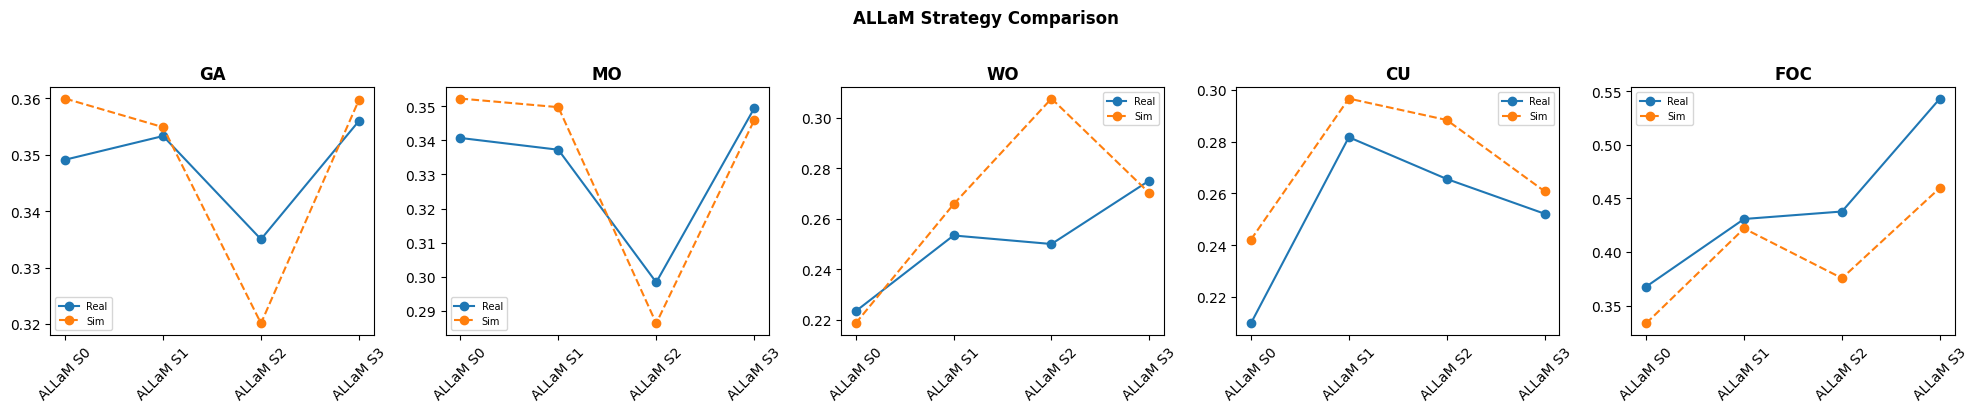

✅ Saved: fig_allam_strategies.png


In [8]:
# ── Figure: ALLaM strategy comparison ───────────────────────────────────────
allam_suffixes = ['allam_s0','allam_s1','allam_s2','allam_s3']
allam_df = df_all[df_all['Suffix'].isin(allam_suffixes)].copy()

if allam_df.empty:
    print('⚠️  No ALLaM results yet. Run allam_experiment.ipynb first.')
else:
    metric_cols = [c for c in ['GA','MO','WO','CU','FOC','FOL','ENG','CO','CH','COR'] if c in allam_df.columns]
    n_metrics = len(metric_cols)
    fig, axes = plt.subplots(1, min(n_metrics, 5), figsize=(4*min(n_metrics,5), 4))
    if n_metrics == 1: axes = [axes]
    strategy_labels = {'allam_s0':'S0 Baseline','allam_s1':'S1 DynFewShot',
                       'allam_s2':'S2 Compress','allam_s3':'S3 Chunking'}
    strategy_colors = ['#956cb4','#8c613c','#dc7ec0','#797979']
    for ax, metric in zip(axes, metric_cols[:5]):
        for src, ls in [('Real','-'),('Sim','--')]:
            sub = allam_df[allam_df['Exp']==src].sort_values('Suffix')
            if sub.empty or metric not in sub.columns: continue
            ax.plot(sub['Model'], sub[metric], marker='o', linestyle=ls, label=src)
        ax.set_title(metric, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.legend(fontsize=7)
    plt.suptitle('ALLaM Strategy Comparison', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE,'figures_and_tables','fig_allam_strategies.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: fig_allam_strategies.png')


In [9]:
# ── Token overflow analysis for S0 (Baseline) ───────────────────────────────
# Count empty responses (empty agent output = token overflow)
s0_real = results.get(('allam_s0','real'),{})
if s0_real:
    dur = s0_real['dur']
    # agent produced no output → agent_gaze_aoi_id is NaN or -1
    empty = dur['agent_gaze_aoi_id'].isna().sum()
    total = len(dur)
    print(f'S0 Baseline — Real:')
    print(f'  Total rows:   {total}')
    print(f'  Empty output: {empty} ({100*empty/total:.1f}%)')
    print(f'  Valid output: {total-empty} ({100*(total-empty)/total:.1f}%)')
else:
    print('ℹ️  S0 results not available yet.')
    print('   Run Cell 8 in allam_experiment.ipynb first.')


S0 Baseline — Real:
  Total rows:   12990
  Empty output: 10685 (82.3%)
  Valid output: 2305 (17.7%)


In [10]:
# ── Final comparison table: Best ALLaM strategy vs other models ─────────────
if not allam_df.empty and 'CH' in df_all.columns:
    # Find best ALLaM strategy by CH on Real
    real_allam = allam_df[allam_df['Exp']=='Real']
    if not real_allam.empty:
        best_allam_idx = real_allam['CH'].idxmax()
        best_allam = real_allam.loc[best_allam_idx, 'Model']
        print(f'Best ALLaM strategy (by CH, Real): {best_allam}')
    print()

# Summary table
summary_cols = ['Model','Exp','N']
for c in ['GA','MO','CH','COR']:
    if c in df_all.columns: summary_cols.append(c)
print('\n=== Summary: Key Metrics ===\n')
summary = df_all[summary_cols].copy()
for c in ['GA','MO']:
    if c in summary.columns: summary[c] = summary[c].map('{:.3f}'.format)
for c in ['CH','COR']:
    if c in summary.columns: summary[c] = summary[c].map('{:.1f}'.format)
print(summary.to_string(index=False))

summary.to_csv(os.path.join(BASE,'figures_and_tables','summary_with_allam.csv'), index=False)
print('\n✅ Saved: figures_and_tables/summary_with_allam.csv')


Best ALLaM strategy (by CH, Real): ALLaM S3


=== Summary: Key Metrics ===

      Model  Exp   N    GA    MO   CH  COR
    GPT-3.5 Real 301 0.338 0.304 46.9 55.6
    GPT-3.5  Sim 300 0.352 0.330 46.6 55.6
GPT-4o Mini Real 301 0.371 0.327 61.9 66.1
GPT-4o Mini  Sim 300 0.372 0.329 61.1 66.0
  Llama 3.1 Real 301 0.355 0.334 45.7 55.7
  Llama 3.1  Sim 300 0.369 0.356 45.0 55.4
    Qwen2.5 Real 301 0.390 0.348 57.4 62.0
    Qwen2.5  Sim 300 0.375 0.338 56.9 61.3
   ALLaM S0 Real 300 0.349 0.341 48.6 56.1
   ALLaM S0  Sim   8 0.360 0.352 56.2 59.4
   ALLaM S1 Real 300 0.353 0.337 47.8 57.8
   ALLaM S1  Sim 300 0.355 0.350 47.6 58.2
   ALLaM S2 Real 300 0.335 0.298 48.7 58.2
   ALLaM S2  Sim 300 0.320 0.286 48.8 58.6
   ALLaM S3 Real 300 0.356 0.349 50.8 58.6
   ALLaM S3  Sim 300 0.360 0.346 43.4 55.1

✅ Saved: figures_and_tables/summary_with_allam.csv
